# 条件生成对抗网络（Conditional GAN）实现 - CIFAR-10

## Conditional GAN原理

条件生成对抗网络（Conditional GAN，简称CGAN）是Ian Goodfellow等人提出的GAN的一个重要扩展，由Mehdi Mirza和Simon Osindero在2014年提出。CGAN通过在生成器和判别器中引入额外的辅助信息（如类标签），实现了对生成过程的有条件控制。

### CGAN的基本思想

普通GAN的主要局限性在于生成过程缺乏控制性——我们无法指定要生成的内容类型。CGAN通过在输入中加入条件信息（例如类别标签）来克服这一局限：

- **生成器（Generator）**: 同时接收随机噪声和条件信息作为输入，生成符合条件的样本
- **判别器（Discriminator）**: 同时接收样本和条件信息作为输入，判断样本在给定条件下是真实的还是生成的

这种条件机制允许GAN学习生成特定类型的数据，并且可以在测试阶段通过改变条件来控制生成结果。

### CGAN的数学表达

#### 数学模型

假设：
- $x$: 数据样本
- $y$: 条件信息（如类标签）
- $z$: 随机噪声
- $G(z,y)$: 条件生成器，将噪声和条件映射到数据空间
- $D(x,y)$: 条件判别器，在给定条件下评估数据是真实的概率

#### CGAN的目标函数

CGAN的训练可以表示为以下的极小极大博弈：

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x|y)}[\log D(x|y)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z|y)|y))]$$

其中：
- $p_{data}(x|y)$: 在条件$y$下真实数据的分布
- $p_z(z)$: 随机噪声的分布（通常是均匀分布或高斯分布）
- $D(x|y)$: 在给定条件$y$下，判别器判断数据$x$为真实的概率
- $G(z|y)$: 在给定条件$y$下，生成器将噪声$z$转换为模拟数据

#### 训练目标

在这个框架下：
- 判别器$D$试图最大化$V(D,G)$，即正确区分在各种条件下的真实数据和生成数据
- 生成器$G$试图最小化$V(D,G)$，即生成能够在给定条件下欺骗判别器的数据

实际训练中，生成器通常优化以下目标函数以避免梯度消失：

$$\max_G \mathbb{E}_{z \sim p_z(z)}[\log D(G(z|y)|y)]$$

### 条件嵌入方式

条件信息可以通过多种方式嵌入到网络中：

1. **连接（Concatenation）**：
   - 在生成器中，将条件信息与随机噪声连接后输入网络
   - 在判别器中，将条件信息与输入数据（或中间特征）连接后处理

2. **条件批归一化（Conditional Batch Normalization）**：
   - 使用条件信息调制批归一化层的缩放和偏移参数

3. **嵌入（Embedding）**：
   - 将类别等条件信息通过嵌入层转换为密集向量
   - 然后通过连接或投影方式与主要数据流结合

### CGAN的优势

1. **生成过程可控**：能够生成特定类别或特征的样本
2. **改善生成质量**：条件信息提供了额外的结构，有助于提高生成质量
3. **多样性与一致性**：在保持类间多样性的同时，提高类内一致性
4. **应用广泛**：适用于图像生成、文本到图像转换、风格迁移等多种任务

### CGAN的挑战

1. **条件覆盖不足**：如果训练数据中某些条件组合较少，相应生成能力可能受限
2. **条件嵌入设计**：如何有效地将条件信息融入网络是一个关键挑战
3. **模式崩塌**：在条件空间中仍可能出现模式崩塌（mode collapse）问题

> 本实现采用CGAN架构生成CIFAR-10数据集的类条件图像，通过嵌入层处理类别标签并与主要数据流结合。

## 环境设置

In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

MODEL_SAVE_PATH = "../model/conditional_gan"
RESULT_SAVE_PATH = "../result/conditional_gan"

Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)
Path(RESULT_SAVE_PATH).mkdir(parents=True, exist_ok=True)

Using device: mps


## 超参数设置

条件生成对抗网络（Conditional GAN）的训练需要精心设置多个超参数，这些参数会影响模型的收敛性、稳定性和生成结果质量：

- `batch_size`: 每批训练的样本数量，影响优化过程和内存消耗
- `image_size`: 图像尺寸，CIFAR-10为32x32像素
- `nc`: 图像通道数，RGB图像为3通道
- `nz`: 潜在噪声向量的维度，控制随机性空间
- `ngf`: 生成器中特征图的基准大小
- `ndf`: 判别器中特征图的基准大小
- `num_classes`: 条件类别数量，CIFAR-10包含10个类别
- `num_epochs`: 训练的总轮数
- `lr`: 学习率，通常CGAN使用较小的学习率以增强稳定性
- `beta1`: Adam优化器的动量参数，控制一阶矩估计的指数衰减率

与普通GAN相比，CGAN还需要考虑条件信息的嵌入维度和融合方式，这会影响条件控制的有效性。

In [ ]:
batch_size = 128
image_size = 32
nc = 3  # 图像通道数 (RGB)
nz = 100  # 潜在向量z的大小
ngf = 64  # 生成器中特征图的基准大小
ndf = 64  # 判别器中特征图的基准大小
num_classes = 10  # CIFAR-10的类别数量
num_epochs = 100
lr = 0.0002  # 学习率
beta1 = 0.5  # Adam优化器的beta1参数

In [ ]:
# 数据预处理：转换为张量并标准化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # 将像素值标准化到[-1,1]范围
])

# 加载CIFAR-10数据集
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# 创建数据加载器
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

## 模型权重初始化

模型权重的初始化对GAN的训练非常重要，良好的初始化有助于提升训练的稳定性和收敛速度。

在CGAN中，我们采用与DCGAN（深度卷积生成对抗网络）相似的初始化策略：

1. **卷积层初始化**：使用均值为0、标准差为0.02的正态分布
2. **批归一化层初始化**：
   - 权重使用均值为1、标准差为0.02的正态分布
   - 偏置初始化为0

这种初始化方式有助于：
- 在训练初期产生较为合理的梯度大小
- 避免特征尺度不一致问题
- 减少模式崩溃和训练不稳定的可能性

下面的`weights_init`函数实现了这一初始化策略，将被应用于生成器和判别器网络。

In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## 条件生成器和判别器网络架构

条件生成对抗网络（CGAN）的核心是将条件信息融入到生成器和判别器中。在本实现中，我们使用类标签作为条件信息，并通过嵌入层处理这些标签。

### 条件生成器（`ConditionalGenerator`）

条件生成器接收两个输入：随机噪声向量和类别标签。其主要组件包括：

1. **标签嵌入层**：将整数类标签转换为密集的嵌入向量
2. **输入处理**：将噪声向量和嵌入向量拼接后通过全连接层处理
3. **上采样网络**：使用转置卷积层逐步将低维特征图扩展为全尺寸图像

生成器的结构遵循DCGAN设计，使用批归一化和ReLU激活函数，最终输出通过Tanh激活函数将像素值压缩到[-1,1]范围内。

### 条件判别器（`ConditionalDiscriminator`）

条件判别器同样接收两个输入：图像和类别标签。主要组件包括：

1. **初始特征提取**：首先处理输入图像，提取初步特征
2. **标签嵌入和融合**：将类标签嵌入后扩展为与图像特征相同的空间尺寸，然后进行拼接
3. **鉴别网络**：使用卷积层逐步降维，最终输出一个判断真假的概率值

判别器使用LeakyReLU激活函数避免"死亡ReLU"问题，并在除第一层外的所有卷积层后使用批归一化来稳定训练。

这种架构允许网络学习不同类别的特征分布，并根据给定的类别标签生成对应类别的图像。

In [5]:
class ConditionalGenerator(nn.Module):
    def __init__(self):
        super(ConditionalGenerator, self).__init__()
        
        # Embedding layer for conditioning
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        
        # Noise and condition processing
        self.fc = nn.Linear(nz + num_classes, ngf * 4 * 4 * 4)
        
        # Transposed convolution layers
        self.main = nn.Sequential(
            # state size. (ngf*4) x 4 x 4
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 8 x 8
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 16 x 16
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 32 x 32
        )

    def forward(self, noise, labels):
        # Embed labels
        label_embedding = self.label_embedding(labels)
        
        # Concatenate noise and embedded labels
        combined_input = torch.cat((noise, label_embedding), 1)
        
        # Process through fully connected layer
        x = self.fc(combined_input)
        
        # Reshape
        x = x.view(-1, ngf * 4, 4, 4)
        
        # Process through transposed convolution layers
        return self.main(x)

# Conditional Discriminator Network
class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super(ConditionalDiscriminator, self).__init__()
        
        # Embedding layer for conditioning
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        
        # Image processing without condition
        self.conv1 = nn.Conv2d(nc, ndf, 4, 2, 1, bias=False)
        
        # Process image with condition
        self.main = nn.Sequential(
            # state size. (ndf+num_classes) x 16 x 16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf + num_classes, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        # Process image
        x = self.conv1(image)
        
        # Embed labels
        batch_size, _, height, width = x.shape
        label_embedding = self.label_embedding(labels)
        
        # Reshape label embedding to be concatenated with the image features
        label_embedding = label_embedding.view(batch_size, -1, 1, 1)
        label_embedding = label_embedding.expand(batch_size, num_classes, height, width)
        
        # Concatenate image features and label embedding
        x = torch.cat((x, label_embedding), 1)
        
        # Process through the rest of the network
        return self.main(x)

# Initialize networks
netG = ConditionalGenerator().to(device)
netD = ConditionalDiscriminator().to(device)

# Apply custom weights initialization
netG.apply(weights_init)

ConditionalGenerator(
  (label_embedding): Embedding(10, 10)
  (fc): Linear(in_features=110, out_features=4096, bias=True)
  (main): Sequential(
    (0): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): Tanh()
  )
)

In [6]:
netD.apply(weights_init)

ConditionalDiscriminator(
  (label_embedding): Embedding(10, 10)
  (conv1): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (main): Sequential(
    (0): LeakyReLU(negative_slope=0.2, inplace=True)
    (1): Conv2d(74, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (8): Sigmoid()
  )
)

In [7]:
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

## 固定标签集和噪声向量的创建

为了在训练过程中监控生成器的进步，创建一组固定的噪声向量和标签，并在每个评估点使用它们生成图像。这将能够：

1. **追踪生成质量的提高**：使用相同的噪声和标签，我们可以直接比较不同训练阶段的生成结果
2. **验证条件控制的有效性**：确保生成器正确学习了类别条件，生成的图像与指定的类别相符
3. **可视化学习过程**：通过可视化中间结果，更直观地了解模型的学习情况

本实验创建了100个固定的噪声向量，并为其分配了均匀分布的类别标签（每个类别10个样本），这将用于定期生成样本图像。

In [8]:
def create_labels():
    labels = []
    for i in range(10):  # 10 classes
        labels += [i] * 10  # 10 samples per class
    return torch.tensor(labels, device=device)

In [9]:
fixed_noise = torch.randn(100, nz, device=device)
fixed_labels = create_labels()

# Lists to keep track of progress
G_losses = []
D_losses = []
img_list = []

## Conditional GAN的训练过程

主要步骤如下：

### 训练流程

1. **判别器训练**:
   - 使用真实图像和其真实标签训练判别器识别真实样本
   - 使用生成器生成的假图像和随机标签训练判别器识别假样本
   - 结合两部分损失更新判别器参数

2. **生成器训练**:
   - 生成假图像并使用随机标签作为条件
   - 目标是使判别器将这些假图像误判为在给定标签条件下的真实图像
   - 更新生成器参数

3. **监控与评估**:
   - 跟踪生成器和判别器的损失
   - 使用固定噪声和标签定期生成样本，评估生成质量
   - 保存模型检查点和生成样本

为了稳定训练，本实验使用以下技巧：
- 使用单独的优化器分别更新生成器和判别器
- 应用Adam优化器，参数针对GAN训练进行调整
- 使用进度条跟踪训练状态，提供实时反馈

Epoch 1/100: 100%|██████████| 391/391 [00:43<00:00,  9.02it/s, Loss_D=0.4945, Loss_G=3.8731, D(x)=0.8572, D(G(z))=0.2603/0.0269]



Epoch 1/100 Summary:
Average Loss_D: 0.5414, Average Loss_G: 3.4391
Average D(x): 0.7995, Average D(G(z)): 0.1929/0.0809
Model saved at epoch 1


Epoch 2/100: 100%|██████████| 391/391 [00:40<00:00,  9.65it/s, Loss_D=1.0578, Loss_G=3.6429, D(x)=0.7714, D(G(z))=0.5051/0.0406]


Epoch 2/100 Summary:
Average Loss_D: 0.7168, Average Loss_G: 2.5523
Average D(x): 0.7368, Average D(G(z)): 0.2592/0.1185



Epoch 3/100: 100%|██████████| 391/391 [00:37<00:00, 10.45it/s, Loss_D=1.0512, Loss_G=3.5708, D(x)=0.8823, D(G(z))=0.5485/0.0381]

...


Epoch 98/100 Summary:
Average Loss_D: 0.2322, Average Loss_G: 3.6286
Average D(x): 0.9032, Average D(G(z)): 0.0963/0.0593



Epoch 99/100: 100%|██████████| 391/391 [00:30<00:00, 13.02it/s, Loss_D=0.1351, Loss_G=4.0758, D(x)=0.9533, D(G(z))=0.0681/0.0375] 


Epoch 99/100 Summary:
Average Loss_D: 0.3687, Average Loss_G: 3.7171
Average D(x): 0.8836, Average D(G(z)): 0.1165/0.0778



Epoch 100/100: 100%|██████████| 391/391 [00:30<00:00, 12.99it/s, Loss_D=0.4422, Loss_G=2.6266, D(x)=0.7304, D(G(z))=0.0487/0.1308] 



Epoch 100/100 Summary:
Average Loss_D: 0.3442, Average Loss_G: 3.7604
Average D(x): 0.8920, Average D(G(z)): 0.1076/0.0688
Model saved at epoch 100
Final model saved


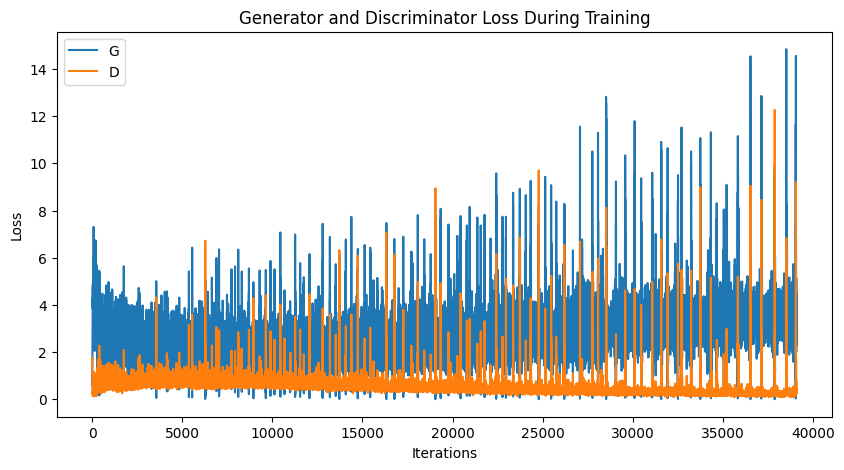

In [10]:
from tqdm import tqdm

for epoch in range(num_epochs):
    # Create progress bar for this epoch
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch+1}/{num_epochs}")
    
    # Track epoch losses
    epoch_G_loss = 0
    epoch_D_loss = 0
    epoch_D_x = 0
    epoch_D_G_z1 = 0
    epoch_D_G_z2 = 0
    num_batches = 0
    
    for i, data in pbar:
        real_images, real_labels = data
        real_images = real_images.to(device)
        real_labels = real_labels.to(device)
        batch_size = real_images.size(0)
        
        ############################
        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        netD.zero_grad()
        
        # Train with real batch
        label = torch.full((batch_size,), 1, dtype=torch.float, device=device)
        output = netD(real_images, real_labels).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()
        
        # Train with fake batch
        noise = torch.randn(batch_size, nz, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_images = netG(noise, fake_labels)
        label.fill_(0)
        output = netD(fake_images.detach(), fake_labels).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()
        
        ############################
        # (2) Update Generator: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(1)  # Fake labels are real for generator cost
        output = netD(fake_images, fake_labels).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        
        # Update tqdm progress bar with current metrics
        pbar.set_postfix({
            'Loss_D': f'{errD.item():.4f}',
            'Loss_G': f'{errG.item():.4f}',
            'D(x)': f'{D_x:.4f}',
            'D(G(z))': f'{D_G_z1:.4f}/{D_G_z2:.4f}'
        })
        
        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        
        # Accumulate epoch metrics
        epoch_G_loss += errG.item()
        epoch_D_loss += errD.item()
        epoch_D_x += D_x
        epoch_D_G_z1 += D_G_z1
        epoch_D_G_z2 += D_G_z2
        num_batches += 1
    
    # Calculate and display epoch averages
    avg_G_loss = epoch_G_loss / num_batches
    avg_D_loss = epoch_D_loss / num_batches
    avg_D_x = epoch_D_x / num_batches
    avg_D_G_z1 = epoch_D_G_z1 / num_batches
    avg_D_G_z2 = epoch_D_G_z2 / num_batches
    
    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Average Loss_D: {avg_D_loss:.4f}, Average Loss_G: {avg_G_loss:.4f}")
    print(f"Average D(x): {avg_D_x:.4f}, Average D(G(z)): {avg_D_G_z1:.4f}/{avg_D_G_z2:.4f}")
    
    # Check how the generator is doing by saving G's output on fixed_noise
    if (epoch+1) % 5 == 0 or epoch == 0:
        with torch.no_grad():
            fake = netG(fixed_noise, fixed_labels).detach().cpu()
        img_grid = torchvision.utils.make_grid(fake, nrow=10, padding=2, normalize=True)
        img_list.append(img_grid)
        
        # Save the grid as an image
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Generated Images - Epoch {epoch+1}")
        plt.imshow(np.transpose(img_grid, (1, 2, 0)))
        plt.savefig(f"{RESULT_SAVE_PATH}/conditional_gan_images_epoch_{epoch+1}.png")
        plt.close()
        
        # Save models
        torch.save(netG.state_dict(), f"{MODEL_SAVE_PATH}/conditional_generator_epoch_{epoch+1}.pth")
        torch.save(netD.state_dict(), f"{MODEL_SAVE_PATH}/conditional_discriminator_epoch_{epoch+1}.pth")
        print(f"Model saved at epoch {epoch+1}")

# Save the final model
torch.save(netG.state_dict(), f"{MODEL_SAVE_PATH}/conditional_generator_final.pth")
torch.save(netD.state_dict(), f"{MODEL_SAVE_PATH}/conditional_discriminator_final.pth")
print("Final model saved")

# Plot the training losses
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f'{RESULT_SAVE_PATH}/conditional_gan_loss_plot.png')
plt.show()

## 条件生成与类别控制

条件GAN的一个关键优势是能够控制生成内容的类别或特性。在此实现中，我们通过类别标签控制生成的图像类型，使模型能够根据指定的类别生成相应的图像。

### 条件生成的优势

1. **目标导向生成**：能够生成属于特定类别的图像，而不仅仅是随机样本
2. **增强多样性**：可以覆盖所有类别的样本，避免模型只专注于某些容易生成的类别
3. **评估简化**：可以针对特定类别评估生成质量，便于发现模型在不同类别上的表现差异

### 生成策略

在我们的可视化中，我们采用两种方式展示条件生成能力：

1. **网格可视化**：创建一个10×10的网格，每行代表一个类别，显示该类别下生成的多个样本
2. **类别批量生成**：为每个类别生成一批样本，展示模型在不同类别上的生成能力

通过这些可视化，我们可以评估：
- 模型是否真正学习了类别条件（生成的图像是否符合指定类别）
- 条件控制的精确度（类内相似性和类间差异性）
- 生成图像的多样性和质量

CIFAR-10数据集包含10个类别：飞机、汽车、鸟类、猫、鹿、狗、青蛙、马、船和卡车。我们的目标是生成器能够针对每个类别生成符合特征的图像。

Generating final class-conditional images...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9945096..0.9920736].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99147034..0.9305999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99304557..0.8647033].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.93794876..0.89711833].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.93845034..0.9999992].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.80544406..0.72206444].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0

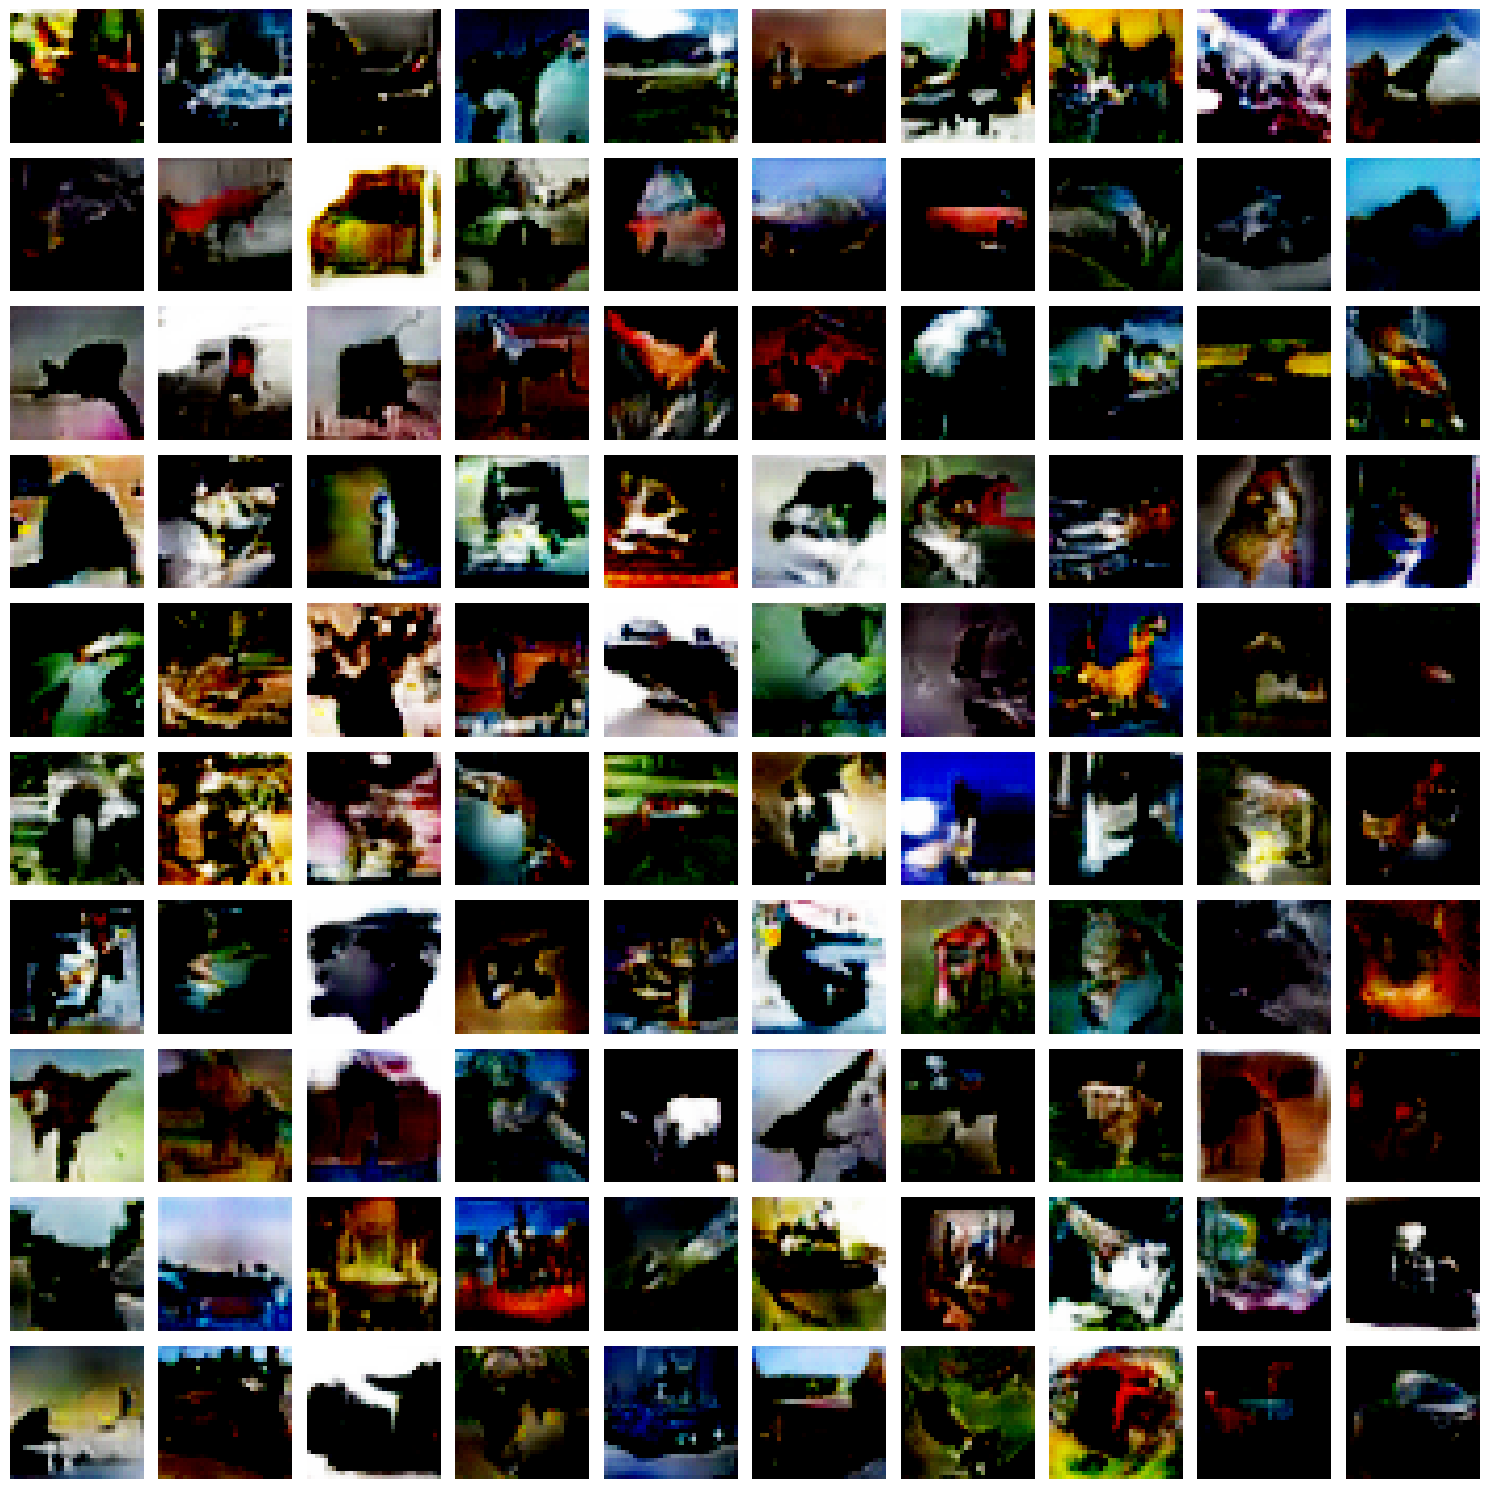

Class conditional image generation complete


In [11]:
# Generate a final visualization showing generated images for each class
print("Generating final class-conditional images...")

# Create a grid with 10 examples for each of the 10 classes
n_rows = 10  # Number of classes
n_cols = 10  # Number of examples per class
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))

# CIFAR-10 class names for labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Generate 10 examples for each class
with torch.no_grad():
    for class_idx in range(n_rows):
        # Create noise and fixed class labels
        noise = torch.randn(n_cols, nz, device=device)
        labels = torch.full((n_cols,), class_idx, device=device)
        
        # Generate images
        fake = netG(noise, labels).detach().cpu()
        
        # Display the images
        for col_idx in range(n_cols):
            ax = axes[class_idx, col_idx]
            img = np.transpose(fake[col_idx], (1, 2, 0))
            ax.imshow(img)
            if col_idx == 0:  # Add class label on the left
                ax.set_ylabel(class_names[class_idx], fontsize=12)
            ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/conditional_gan_class_samples.png')
plt.show()
print("Class conditional image generation complete")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7246136..0.982999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90270334..0.8011552].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71995705..0.9628204].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8222959..0.9237975].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6947609..0.99798024].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9528748..0.9590931].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9234

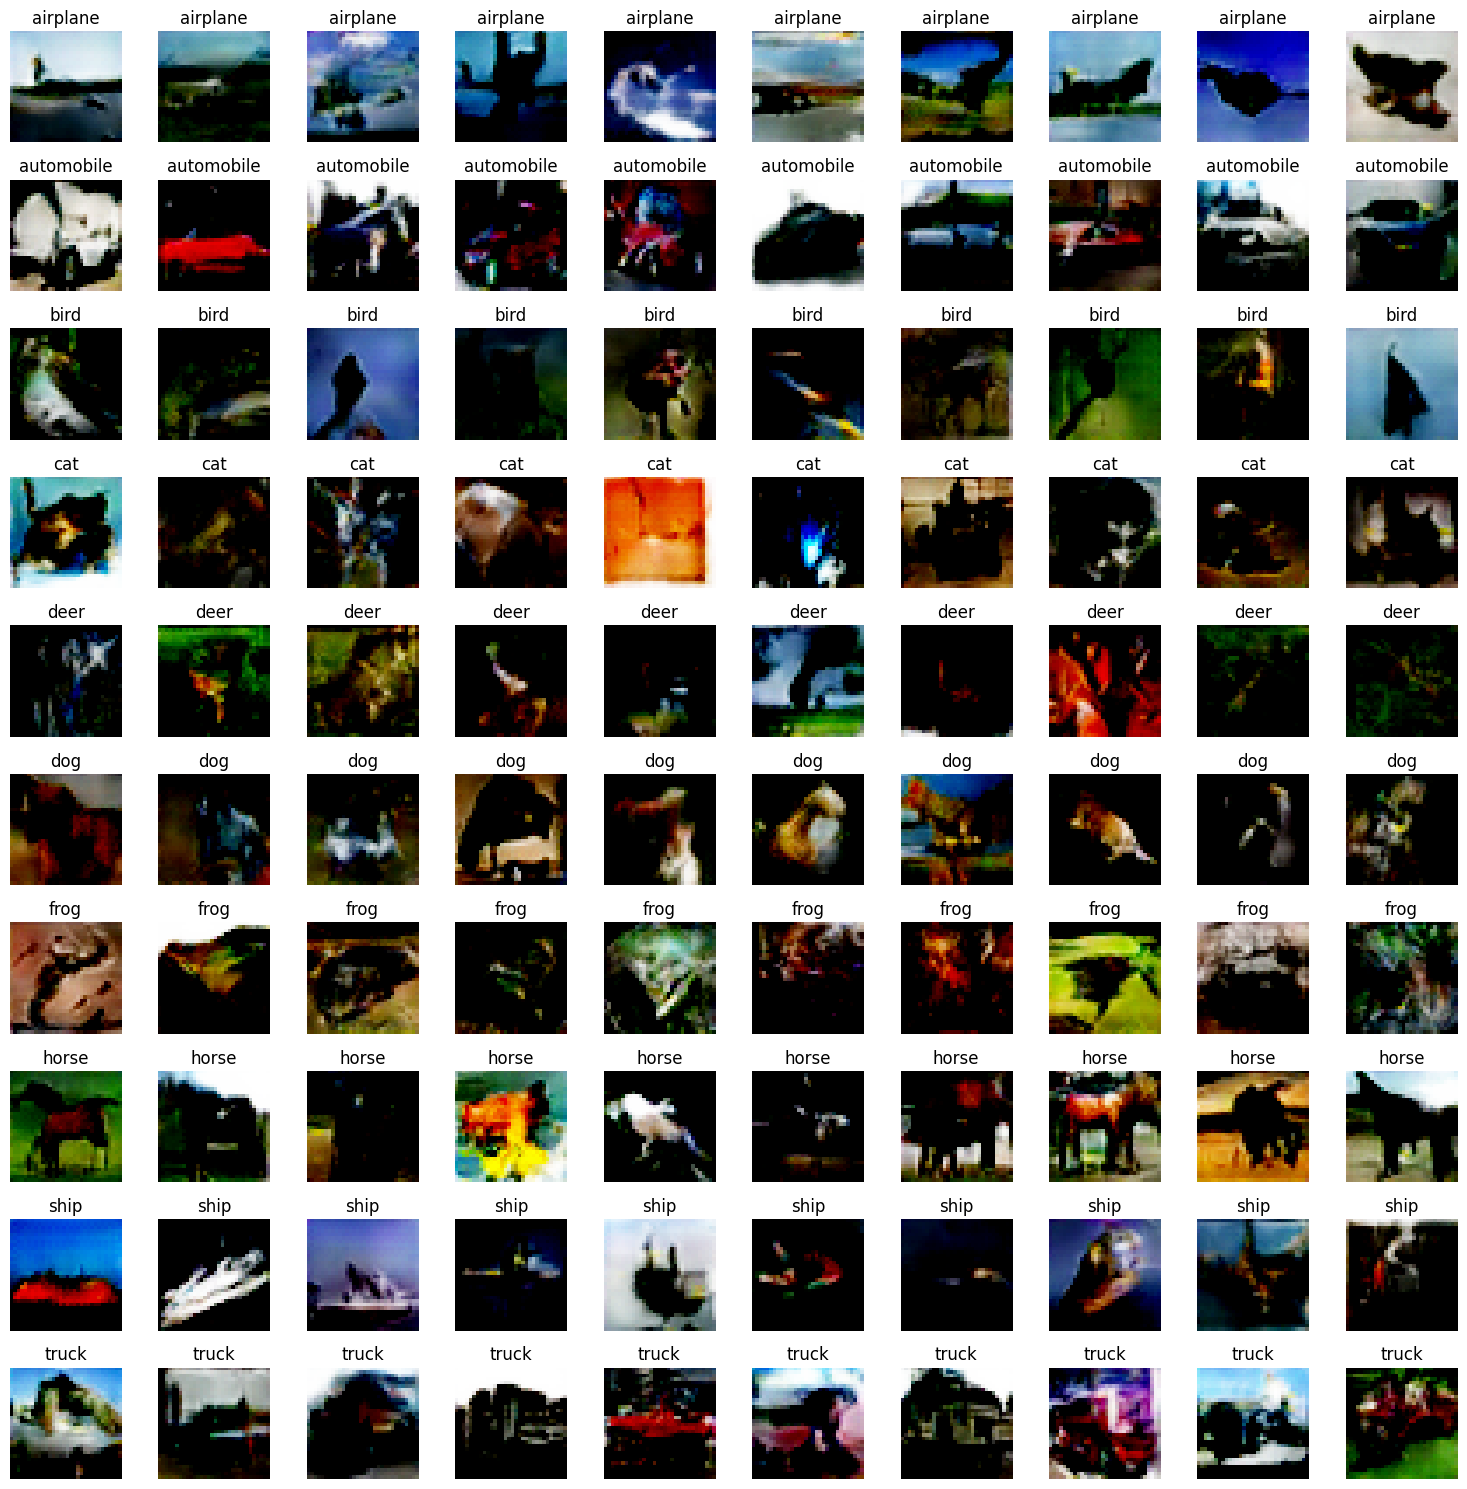

In [12]:
# Display a batch of generated images with class labels
def show_images_with_labels(imgs, labels, num_classes=10, samples_per_class=10):
    """Display images with their class labels."""
    plt.figure(figsize=(15, 15))
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    for i in range(num_classes):
        for j in range(samples_per_class):
            idx = i * samples_per_class + j
            plt.subplot(num_classes, samples_per_class, idx + 1)
            plt.imshow(np.transpose(imgs[idx], (1, 2, 0)))
            plt.title(class_names[labels[idx]])
            plt.axis('off')
            
    plt.tight_layout()
    plt.savefig(f'{RESULT_SAVE_PATH}/conditional_gan_generated_images.png')
    plt.show()

# Generate images for each class
with torch.no_grad():
    # Generate images using fixed noise and labels
    generated_images = netG(fixed_noise, fixed_labels).detach().cpu()
    
    # Display the generated images with their class labels
    show_images_with_labels(generated_images, fixed_labels.cpu())

# Conditional GAN总结与进阶方向

本实现展示了一个基于深度卷积网络的条件生成对抗网络（CGAN），应用于CIFAR-10图像数据集。通过将类别信息融入生成过程，模型能够根据指定的类别生成相应的图像。

## 关键技术要点

- **条件嵌入**：通过嵌入层处理类别标签，并将其融入到生成器和判别器中
- **深度卷积结构**：使用转置卷积和常规卷积分别构建生成器和判别器
- **批归一化**：使用批归一化层稳定训练过程
- **可视化评估**：通过类别条件生成和网格展示评估模型性能

## 可能的改进方向

1. **架构改进**：
   - 引入自注意力机制（如SAGAN）增强生成质量
   - 使用谱归一化（Spectral Normalization）稳定判别器训练
   - 尝试投影判别器（Projection Discriminator）改进条件融合

2. **训练策略优化**：
   - 实现渐进式增长训练（Progressive Growing）
   - 使用一致性正则化（Consistency Regularization）
   - 尝试差异化增强（Differentiable Augmentation）改善小数据集训练

3. **条件控制增强**：
   - 扩展到多条件控制（如类别+属性）
   - 实现连续条件控制（如风格强度）
   - 尝试无监督条件发现（如InfoGAN）

4. **评估方法**：
   - 实现FID（Fréchet Inception Distance）定量评估生成质量
   - 计算类别准确率评估条件控制有效性
   - 进行用户研究评估生成图像的真实度和可识别性

条件GAN是深度生成模型的重要分支，为可控图像生成提供了强大工具。通过进一步探索和改进，可以应用于图像编辑、风格迁移、数据增强等广泛领域。